# Arabic Dialect Identification using Classical Machine Learning

This notebook implements a complete pipeline for identifying Arabic dialects from speech audio using **classical ML only** (no deep learning).

### Pipeline Overview
1. Load the `riotu-lab/ARCADE-full` dataset from Hugging Face
2. Select 4 geographically distinct dialects and build a balanced subset
3. Extract MFCC features using paper-specified constants
4. Train a KNN classifier with distance-weighted voting
5. Evaluate with accuracy, F1, confusion matrix, and probability predictions

---

## Install & Import Dependencies

In [1]:
# Install required packages (run once in your environment)
# !pip install datasets librosa scikit-learn seaborn matplotlib soundfile

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

from datasets import load_dataset
from collections import Counter

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully.")
print(f"  librosa version : {librosa.__version__}")

✅ All libraries imported successfully.
  librosa version : 0.11.0


---
## Load the ARCADE Dataset

We load the full dataset from Hugging Face. The first run will download and cache the audio files locally. Subsequent runs read from the cache.

In [2]:
print("⏳ Loading riotu-lab/ARCADE-full from Hugging Face ...")
ds = load_dataset("riotu-lab/ARCADE-full")
print("✅ Dataset loaded.")
print(ds)

⏳ Loading riotu-lab/ARCADE-full from Hugging Face ...


README.md: 0.00B [00:00, ?B/s]

full_dataset/train-00000-of-00009.parque(…):   0%|          | 0.00/473M [00:00<?, ?B/s]

full_dataset/train-00001-of-00009.parque(…):   0%|          | 0.00/412M [00:00<?, ?B/s]

full_dataset/train-00002-of-00009.parque(…):   0%|          | 0.00/448M [00:00<?, ?B/s]

...

full_dataset/train-00006-of-00009.parque(…):   0%|          | 0.00/430M [00:00<?, ?B/s]

full_dataset/train-00007-of-00009.parque(…):   0%|          | 0.00/451M [00:00<?, ?B/s]

full_dataset/train-00008-of-00009.parque(…):   0%|          | 0.00/395M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6907 [00:00<?, ? examples/s]

✅ Dataset loaded.
DatasetDict({
    train: Dataset({
        features: ['audio', 'filename', 'duration', 'country', 'city', 'msa_or_dialect', 'emotion', 'keep_or_skip', 'confidence', 'audio_type', 'annotators', 'timestamp'],
        num_rows: 6907
    })
})


---
## Dataset Exploration

Before filtering, we inspect the dataset structure to identify:
- Which split(s) are available (`train`, `test`, `validation`)
- The exact column name that holds dialect labels
- All distinct dialect classes and their frequencies

In [3]:
# --- Determine the usable split ---
available_splits = list(ds.keys())
print(f"Available splits: {available_splits}")

# Use 'train' if present, otherwise fall back to the first split
SPLIT = 'train' if 'train' in available_splits else available_splits[0]
dataset = ds[SPLIT]
print(f"\nUsing split : '{SPLIT}'  ({len(dataset):,} samples)")

# --- Show a few rows ---
sample_row = dataset[0]
print("\n--- First row (non-audio fields) ---")
for k, v in sample_row.items():
    if k != 'audio':
        print(f"  {k}: {v}")

# FIX: Do not call .keys(), just access the elements directly
audio_data = sample_row['audio']
print(f"\n--- Audio Field ---")
print(f"  audio array shape: {np.array(audio_data['array']).shape}")
print(f"  audio sampling_rate: {audio_data['sampling_rate']}")

Available splits: ['train']

Using split : 'train'  (6,907 samples)

--- First row (non-audio fields) ---
  filename: F-wgr9Z8jFs_segment_01.mp3
  duration: 29.99
  country: Algeria
  city: Annaba
  msa_or_dialect: MSA
  emotion: Neutral
  keep_or_skip: Keep
  confidence: sure
  audio_type: Multiple speakers
  annotators: Waad
  timestamp: 2025-08-04T03:15:00.741310

--- Audio Field ---
  audio array shape: (1439471,)
  audio sampling_rate: 48000


In [4]:
from collections import Counter

# -----------------------------------------------------------------------
# 1. Filter out non-dialect audio (MSA, Mixed, etc.)
# -----------------------------------------------------------------------
print("Filtering out MSA and Mixed audio...")
dataset = dataset.filter(lambda x: x['msa_or_dialect'] == 'Dialect')

# -----------------------------------------------------------------------
# 2. Set the label column manually to 'country'
# -----------------------------------------------------------------------
LABEL_COL = 'country'
print(f"✅ Label column set to: '{LABEL_COL}'")

# -----------------------------------------------------------------------
# 3. Count all dialect occurrences
# -----------------------------------------------------------------------
all_labels = dataset[LABEL_COL]
label_counts = Counter(all_labels)

print(f"\nAll dialect classes ({len(label_counts)} total countries):")
for dialect, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"  {dialect:40s} : {count:5,} samples")

Filtering out MSA and Mixed audio...


Filter:   0%|          | 0/6907 [00:00<?, ? examples/s]

✅ Label column set to: 'country'

All dialect classes (19 total countries):
  Algeria                                  :   507 samples
  Sudan                                    :   331 samples
  Egypt                                    :   250 samples
  Morocco                                  :   229 samples
  United_Arab_Emirate                      :   213 samples
  Bahrain                                  :   193 samples
  Saudi_Arabia                             :   144 samples
  Palestine                                :   123 samples
  Jordan                                   :   104 samples
  Kuwait                                   :    81 samples
  Yemen                                    :    73 samples
  Iraq                                     :    69 samples
  Somalia                                  :    63 samples
  Syria                                    :    50 samples
  Lebanon                                  :    47 samples
  Libya                                

---
## Select 4 Target Dialects & Build a Balanced Subset

We target one dialect from each major Arabic region:

| Region | Target dialect |
|---|---|
| Egyptian | Egyptian Arabic |
| Gulf | Emirati |
| Levantine | Syrian / Lebanese / Palestinian |
| Maghrebi | Moroccan |

The exact string values below are matched against ARCADE label names — edit `FOUR_DIALECTS` if needed based on the Cell 3 output.

In [5]:
# -----------------------------------------------------------------------
# TARGET DIALECT SELECTION
# Keys   = friendly short names used as class labels throughout the notebook
# Values = substrings that identify the dialect inside the raw label string
#          (case-insensitive match). Updated to match actual dataset country names!
# -----------------------------------------------------------------------
DIALECT_KEYWORDS = {
    'Egyptian'  : ['egypt'],
    'Gulf'      : ['emirate'],
    'Levantine' : ['palestine', 'jordan', 'syria', 'lebanon'],
    'Maghrebi'  : ['morocco']
}

# LOWERED TO 250: Because 'Egyptian' only has 250 samples, and the combined
# Levantine countries only sum up to 324 samples. This ensures a perfectly balanced dataset!
SAMPLES_PER_DIALECT = 250

def match_dialect(label_str: str, keywords: list) -> bool:
    """Return True if label_str contains any keyword (case-insensitive)."""
    label_lower = str(label_str).lower()
    return any(kw.lower() in label_lower for kw in keywords)

# Build a mapping: raw_label_value  ->  friendly_name
raw_label_to_friendly = {}
for label in label_counts.keys():
    for friendly, keywords in DIALECT_KEYWORDS.items():
        if match_dialect(label, keywords):
            raw_label_to_friendly[label] = friendly
            break   # first match wins

# Show matches
print("Label → Friendly mapping found:")
from collections import defaultdict
matched_per_class = defaultdict(list)
for raw, friendly in raw_label_to_friendly.items():
    matched_per_class[friendly].append(raw)

for friendly, raws in matched_per_class.items():
    print(f"  {friendly:12s}: {raws}")

# Verify all 4 classes are found
missing = [k for k in DIALECT_KEYWORDS if k not in matched_per_class]
if missing:
    print(f"\n⚠️  Missing dialect(s): {missing}")
    print("  → Check the raw label strings printed in Cell 3 and update DIALECT_KEYWORDS.")
else:
    print("\n✅ All 4 dialects matched successfully.")

Label → Friendly mapping found:
  Gulf        : ['United_Arab_Emirate']
  Levantine   : ['Jordan', 'Lebanon', 'Palestine', 'Syria']
  Maghrebi    : ['Morocco']
  Egyptian    : ['Egypt']

✅ All 4 dialects matched successfully.


In [6]:
# -----------------------------------------------------------------------
# Build the filtered, balanced subset
# -----------------------------------------------------------------------

# Collect indices per friendly class
class_indices = defaultdict(list)
for idx, raw_label in enumerate(all_labels):
    friendly = raw_label_to_friendly.get(raw_label)
    if friendly is not None:
        class_indices[friendly].append(idx)

# Sample a balanced subset
rng = np.random.default_rng(RANDOM_STATE)
selected_indices = []
selected_labels  = []

for friendly in DIALECT_KEYWORDS.keys():
    idxs = class_indices[friendly]
    n = min(SAMPLES_PER_DIALECT, len(idxs))
    chosen = rng.choice(idxs, size=n, replace=False).tolist()
    selected_indices.extend(chosen)
    selected_labels.extend([friendly] * n)
    print(f"  {friendly:12s}: {n:4d} samples selected (available: {len(idxs):,})")

print(f"\nTotal balanced subset: {len(selected_indices):,} samples")

# Shuffle together
perm = rng.permutation(len(selected_indices))
selected_indices = [selected_indices[i] for i in perm]
selected_labels  = [selected_labels[i]  for i in perm]

DIALECT_NAMES = list(DIALECT_KEYWORDS.keys())  # for consistent ordering
print(f"\nDialect class order: {DIALECT_NAMES}")

  Egyptian    :  250 samples selected (available: 250)
  Gulf        :  213 samples selected (available: 213)
  Levantine   :  250 samples selected (available: 324)
  Maghrebi    :  229 samples selected (available: 229)

Total balanced subset: 942 samples

Dialect class order: ['Egyptian', 'Gulf', 'Levantine', 'Maghrebi']


---
## Mel-Spectrogram Visualisation

Before feature extraction, we visually compare one audio sample from each of the 4 dialects using its Mel-spectrogram. These plots reveal structural differences in frequency energy across dialects.

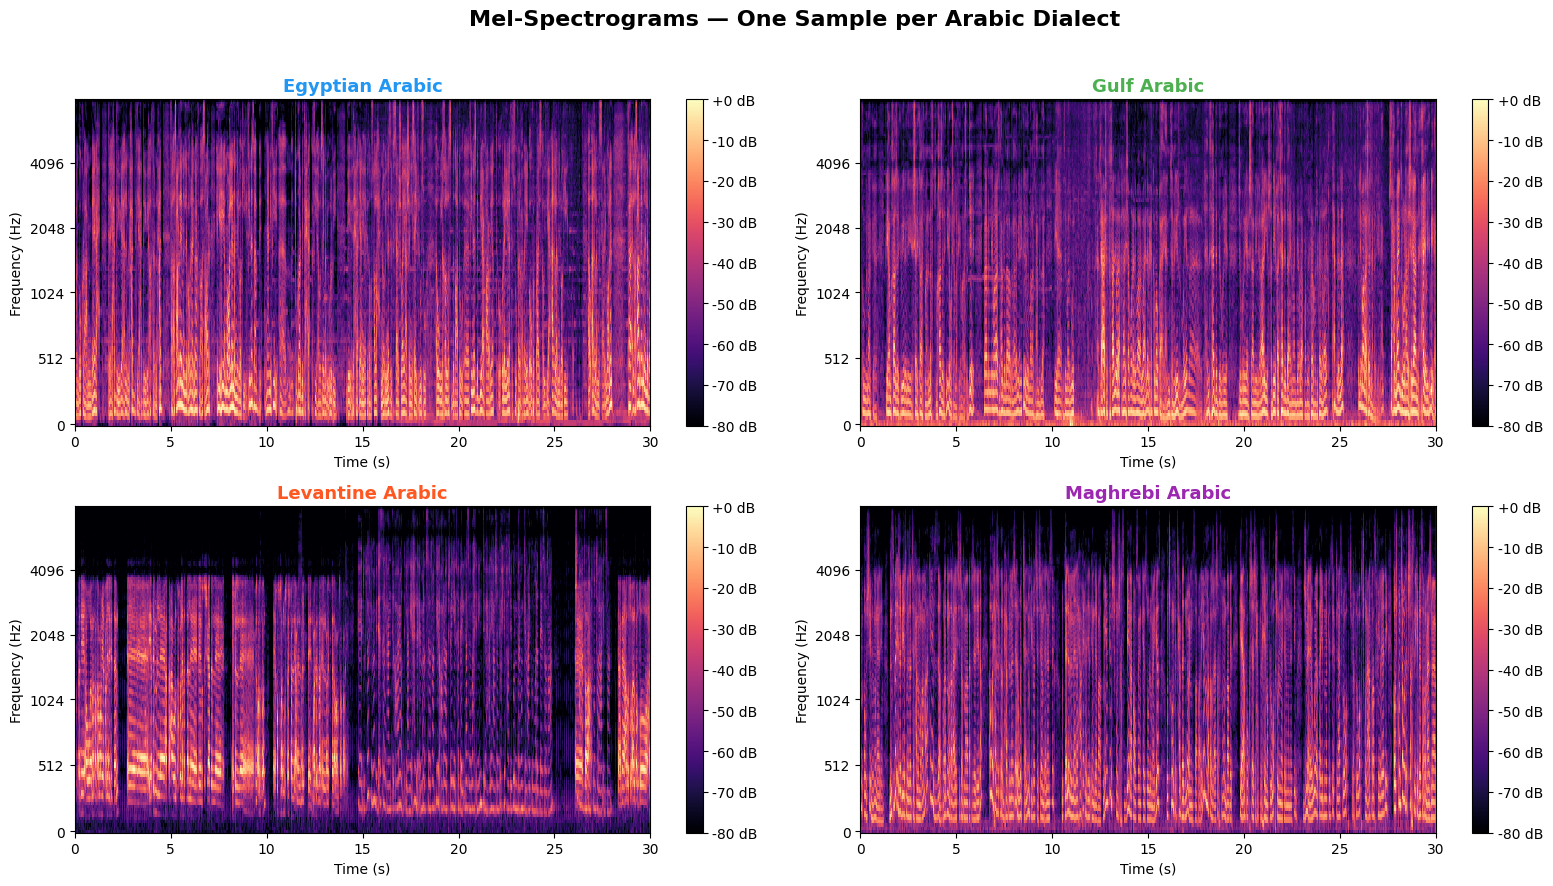

Figure saved as mel_spectrograms.png


In [7]:
TARGET_SR = 16000   # all audio resampled to 16 kHz

def load_and_preprocess(row: dict, target_sr: int = TARGET_SR) -> np.ndarray:
    """
    Extract audio from a Hugging Face dataset row, resample to target_sr,
    and ensure mono format.

    Parameters
    ----------
    row       : dataset row dict with 'audio' key
    target_sr : desired sampling rate (Hz)

    Returns
    -------
    audio : 1-D float32 numpy array at target_sr
    """
    audio_array = np.array(row['audio']['array'], dtype=np.float32)
    sr          = row['audio']['sampling_rate']

    # --- Convert to mono if multi-channel ---
    if audio_array.ndim > 1:
        audio_array = audio_array.mean(axis=-1)

    # --- Resample if necessary ---
    if sr != target_sr:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=target_sr)

    return audio_array


# --- Find one example index per dialect ---
example_indices = {}
for friendly in DIALECT_NAMES:
    # find the first occurrence in our selected_indices for this dialect
    for i, lbl in zip(selected_indices, selected_labels):
        if lbl == friendly:
            example_indices[friendly] = i
            break

# --- Plot Mel-spectrograms ---
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("Mel-Spectrograms — One Sample per Arabic Dialect",
             fontsize=16, fontweight='bold', y=0.98)

PALETTE = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

for ax, (friendly, ds_idx), color in zip(axes.flat, example_indices.items(), PALETTE):
    audio = load_and_preprocess(dataset[ds_idx])

    # Compute Mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio, sr=TARGET_SR, n_mels=128, n_fft=1024, hop_length=512
    )
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    img = librosa.display.specshow(
        mel_db, sr=TARGET_SR, hop_length=512,
        x_axis='time', y_axis='mel', ax=ax, cmap='magma'
    )
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title(f"{friendly} Arabic", fontsize=13, color=color, fontweight='bold')
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.set_ylabel("Frequency (Hz)", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("mel_spectrograms.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as mel_spectrograms.png")

---
## Feature Extraction (Paper-Specified Constants)

Each audio file is processed as follows:

1. **Pre-emphasis filter** (α = 0.97) — boosts high-frequency energy, improving MFCC discriminability  
2. **MFCC extraction** with exact paper constants: `n_mfcc=14`, `n_mels=26`, `n_fft=1103`, `fmin=0`  
3. **Aggregation** — compute **mean** and **std** of each of the 14 MFCCs → **28-dimensional feature vector**

This aggregation converts the variable-length time-series MFCC matrix into a fixed-length 1-D vector suitable for classical ML.

In [8]:
# ---- Paper-specified hyperparameters (DO NOT CHANGE) ----
N_MFCC    = 14
N_MELS    = 26
N_FFT     = 1103
FMIN      = 0       # Hz
PRE_EMPH  = 0.97    # pre-emphasis coefficient
# ---------------------------------------------------------

def apply_preemphasis(audio: np.ndarray, coeff: float = PRE_EMPH) -> np.ndarray:
    """
    Apply a first-order pre-emphasis filter:
        y[n] = x[n] - coeff * x[n-1]

    This is mathematically equivalent to librosa.effects.preemphasis.
    We implement it explicitly to match paper notation.
    """
    return np.append(audio[0], audio[1:] - coeff * audio[:-1])


def extract_features(audio: np.ndarray, sr: int = TARGET_SR) -> np.ndarray:
    """
    Extract a 28-dimensional MFCC feature vector from a mono audio array.

    Steps:
    ------
    1. Apply pre-emphasis (α=0.97)
    2. Compute 14 MFCCs with paper-specified FFT/Mel parameters
    3. Compute per-coefficient mean and std across time frames
    4. Concatenate → [mean_0, ..., mean_13, std_0, ..., std_13]  (28-d)

    Parameters
    ----------
    audio : 1-D float32 numpy array (resampled to TARGET_SR)
    sr    : sampling rate (should always be TARGET_SR=16000)

    Returns
    -------
    feature_vector : 1-D numpy array of shape (28,)
    """
    # Step 1 — Pre-emphasis
    audio_emph = apply_preemphasis(audio, PRE_EMPH)

    # Step 2 — MFCCs with paper constants
    mfcc = librosa.feature.mfcc(
        y       = audio_emph,
        sr      = sr,
        n_mfcc  = N_MFCC,
        n_mels  = N_MELS,
        n_fft   = N_FFT,
        fmin    = FMIN,
    )  # shape: (14, T)

    # Step 3 — Aggregate across time axis
    mfcc_mean = mfcc.mean(axis=1)   # (14,)
    mfcc_std  = mfcc.std(axis=1)    # (14,)

    # Step 4 — Concatenate
    return np.concatenate([mfcc_mean, mfcc_std])  # (28,)


print(f"Feature vector dimensionality: {N_MFCC * 2} (14 means + 14 stds)")
print("\nExtraction parameters:")
print(f"  Pre-emphasis α : {PRE_EMPH}")
print(f"  n_mfcc         : {N_MFCC}")
print(f"  n_mels         : {N_MELS}")
print(f"  n_fft          : {N_FFT}")
print(f"  fmin           : {FMIN} Hz")

# Quick sanity check on one sample
test_audio = load_and_preprocess(dataset[selected_indices[0]])
test_feat  = extract_features(test_audio)
assert test_feat.shape == (28,), f"Expected (28,), got {test_feat.shape}"
print(f"\n✅ Sanity check passed — feature vector shape: {test_feat.shape}")

Feature vector dimensionality: 28 (14 means + 14 stds)

Extraction parameters:
  Pre-emphasis α : 0.97
  n_mfcc         : 14
  n_mels         : 26
  n_fft          : 1103
  fmin           : 0 Hz

✅ Sanity check passed — feature vector shape: (28,)


In [9]:
pd.Series(test_feat)

0    -175.158096
1       6.086910
2       3.062914
3      15.303359
4      -4.081536
5       4.680913
6      -5.087836
7      -0.386536
8      -3.054545
9       0.620130
10     -0.116143
11     -2.894489
12      1.637392
13     -0.549654
14     41.658783
15     22.016993
16     14.719277
17     15.943065
18      9.974991
19      6.661734
20      7.568671
21      5.797112
22      5.572266
23      5.847595
24      4.575570
25      4.462784
26      4.010489
27      3.189985
dtype: float32

In [10]:
# -----------------------------------------------------------------------
# Extract features for ALL selected samples
# This cell may take a few minutes depending on subset size.
# Progress is printed every 100 samples.
# -----------------------------------------------------------------------
from tqdm.auto import tqdm   # pip install tqdm  (usually pre-installed)

N_TOTAL = len(selected_indices)
X_all = np.zeros((N_TOTAL, 28), dtype=np.float32)
y_all = selected_labels  # list of friendly dialect name strings

print(f"Extracting features for {N_TOTAL:,} samples …")

failed = []
for i, ds_idx in enumerate(tqdm(selected_indices)):
    try:
        audio = load_and_preprocess(dataset[ds_idx])
        X_all[i] = extract_features(audio)
    except Exception as e:
        failed.append((i, ds_idx, str(e)))
        X_all[i] = np.zeros(28, dtype=np.float32)  # fallback: zero vector

if failed:
    print(f"\n⚠️  {len(failed)} samples failed feature extraction (filled with zeros):")
    for row in failed[:5]:
        print(f"    sample {row[0]}, ds_idx {row[1]}: {row[2]}")
else:
    print("\n✅ All features extracted without errors.")

print(f"\nFeature matrix shape : X_all = {X_all.shape}")
print(f"Label vector length  : {len(y_all)}")

Extracting features for 942 samples …


  0%|          | 0/942 [00:00<?, ?it/s]


✅ All features extracted without errors.

Feature matrix shape : X_all = (942, 28)
Label vector length  : 942


In [11]:
pd.DataFrame(X_all)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,-175.158096,6.086910,3.062914,15.303359,-4.081536,4.680913,-5.087836,-0.386536,-3.054545,0.620130,...,9.974991,6.661734,7.568671,5.797112,5.572266,5.847595,4.575570,4.462784,4.010489,3.189985
1,-144.963379,19.271172,-14.228252,25.381126,-7.644911,2.326720,-2.626454,-5.177529,-2.673987,-1.779940,...,9.581455,7.235315,7.422766,6.716288,5.552732,4.866024,4.925855,4.352300,4.342613,3.845715
2,-179.562546,5.229607,-0.932086,9.260049,-0.837017,2.503955,-1.563046,-2.617675,-2.869957,1.523873,...,9.875131,7.047579,7.158058,6.537520,4.756934,5.511953,4.698523,4.033737,3.982940,3.252984
3,-137.752563,15.174507,-16.336018,14.094339,0.090651,-8.401662,-0.947814,-7.699378,-3.573084,-0.622907,...,11.532206,11.614738,7.801358,7.962199,6.557424,6.617108,5.865613,4.470186,4.599411,4.599880
4,-129.932770,-5.901040,7.021098,13.242941,6.688533,1.133619,-3.610094,1.153428,-4.478919,2.995205,...,9.178123,7.170423,7.980052,6.004948,5.885871,5.643381,4.929618,4.446790,4.150246,3.632693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937,-240.375168,39.866249,-35.517948,12.145171,-14.643480,-12.456592,-3.089431,-13.570756,0.397746,-4.591934,...,13.853853,10.235879,7.781496,12.783784,6.419533,7.143870,7.998120,6.558089,6.932400,5.953198
938,-154.115005,27.362564,-8.439420,15.910997,-4.972463,-5.219467,-4.031161,-7.371719,-2.531552,-0.682026,...,8.741296,8.824495,7.085888,6.367833,5.201621,5.486271,4.176880,4.561166,3.540216,3.281580
939,-160.346848,0.495530,-5.003708,3.777900,-4.404270,-3.512115,-5.902212,-4.472419,-6.177134,0.731040,...,9.823600,7.682036,8.035341,5.871550,6.246985,5.866444,5.037376,5.035182,4.514203,4.173060
940,-132.754349,-10.702942,3.015548,6.761769,5.307924,-1.169071,-12.372484,2.480181,-8.268321,-3.547067,...,12.414356,8.059615,9.098646,7.828500,6.656647,7.516658,5.289381,5.011217,4.124421,3.099674


---
## Feature Visualisation: PCA Scatter Plot & MFCC Box Plots

We provide two complementary views of the feature space:

- **PCA scatter** — projects all 28 dimensions into 2 principal components for a global overview of class separability
- **MFCC box plots** — shows the distribution of selected individual features (MFCC-4 mean, MFCC-7 std, MFCC-10 mean, MFCC-13 std) where dialect differences are visually apparent

In [12]:
# Initialize without specifying n_components to get the full spectrum
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_all)

# Calculate explained variance metrics
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

print(f"Total components found: {len(exp_var_ratio)}")

Total components found: 28


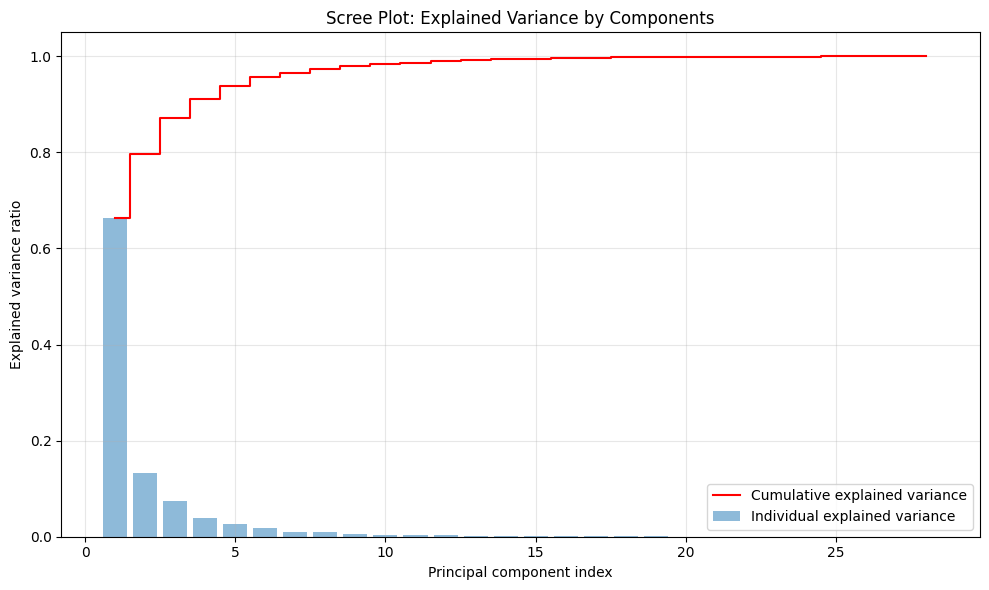

In [13]:
plt.figure(figsize=(10, 6))

# Plot individual variance
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.5,
        align='center', label='Individual explained variance')

# Plot cumulative variance
plt.step(range(1, len(cum_var_ratio) + 1), cum_var_ratio, where='mid',
         label='Cumulative explained variance', color='red')

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot: Explained Variance by Components')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Find number of components for 95% variance
n_95 = np.argmax(cum_var_ratio >= 0.95) + 1

print(f"Number of components to explain 95% variance: {n_95}")

# Now you can re-run PCA or just slice your current transformation
# X_reduced = pca_full.transform(X_all)[:, :n_95]

Number of components to explain 95% variance: 6


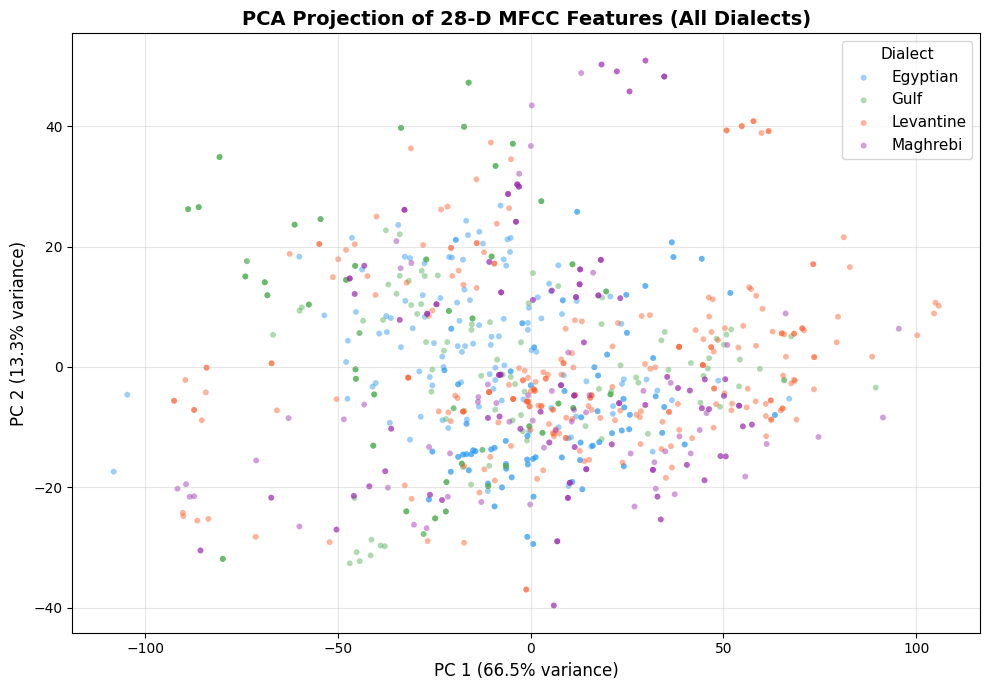

Total explained variance (PC1+PC2): 93.9%


In [15]:
PALETTE_DICT = dict(zip(DIALECT_NAMES, ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']))

# ── PCA to 2 components ──────────────────────────────────────────────────
pca = PCA(n_components=5, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_all)

df_pca = pd.DataFrame({
    'PC1'     : X_pca[:, 0],
    'PC2'     : X_pca[:, 1],
    'Dialect' : y_all,
})

fig, ax = plt.subplots(figsize=(10, 7))
for dialect in DIALECT_NAMES:
    subset = df_pca[df_pca['Dialect'] == dialect]
    ax.scatter(
        subset['PC1'], subset['PC2'],
        c=PALETTE_DICT[dialect], label=dialect,
        alpha=0.45, s=18, edgecolors='none'
    )

explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f"PC 1 ({explained[0]:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC 2 ({explained[1]:.1f}% variance)", fontsize=12)
ax.set_title("PCA Projection of 28-D MFCC Features (All Dialects)",
             fontsize=14, fontweight='bold')
ax.legend(title='Dialect', fontsize=11, title_fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("pca_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Total explained variance (PC1+PC2): {sum(explained):.1f}%")

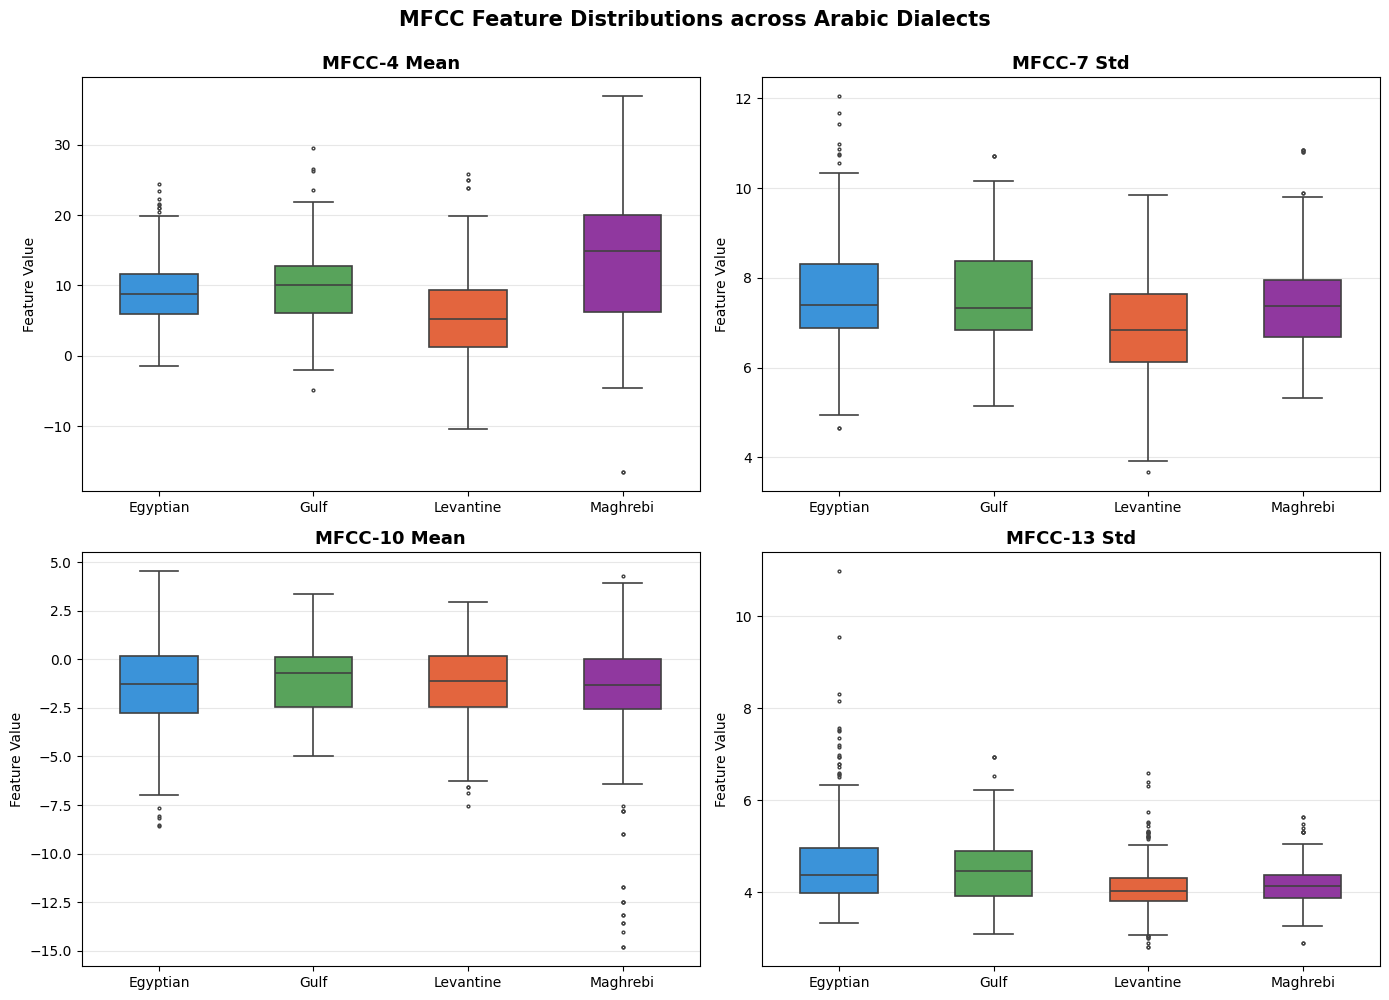

In [16]:
# ── Box plots for selected MFCC features ────────────────────────────────
# Feature index layout:
#   indices 0–13  = MFCC means  (mfcc_mean_0 … mfcc_mean_13)
#   indices 14–27 = MFCC stds   (mfcc_std_0  … mfcc_std_13)

BOXPLOT_FEATURES = {
    'MFCC-4 Mean'  : 3,    # 0-indexed: MFCC coefficient 4 mean
    'MFCC-7 Std'   : 20,   # MFCC coefficient 7 std  (index 14 + 6)
    'MFCC-10 Mean' : 9,    # MFCC coefficient 10 mean
    'MFCC-13 Std'  : 26,   # MFCC coefficient 13 std  (index 14 + 12)
}

df_features = pd.DataFrame(X_all, columns=[f"feat_{i}" for i in range(28)])
df_features['Dialect'] = y_all

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MFCC Feature Distributions across Arabic Dialects",
             fontsize=15, fontweight='bold', y=0.995)

for ax, (feat_name, feat_idx) in zip(axes.flat, BOXPLOT_FEATURES.items()):
    col = f"feat_{feat_idx}"
    sns.boxplot(
        data    = df_features,
        x       = 'Dialect',
        y       = col,
        palette = PALETTE_DICT,
        order   = DIALECT_NAMES,
        width   = 0.5,
        linewidth = 1.2,
        fliersize = 2,
        ax      = ax
    )
    ax.set_title(feat_name, fontsize=13, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Feature Value", fontsize=10)
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("mfcc_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Train / Test Split & Feature Normalisation

We encode string labels to integers, split 80/20, and fit a `StandardScaler` **only on the training set** to avoid data leakage.

In [17]:
# --- Label encoding ---
le = LabelEncoder()
le.fit(DIALECT_NAMES)   # fix class order
y_encoded = le.transform(y_all)

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# --- Train / Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_encoded,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y_encoded   # keep class balance in both splits
)

print(f"\nTrain samples : {X_train.shape[0]:,}")
print(f"Test  samples : {X_test.shape[0]:,}")

# --- StandardScaler (fit on train only) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # use train statistics

print(f"\nFeature mean (post-scale, train): {X_train_scaled.mean():.4f}  (should ≈ 0)")
print(f"Feature std  (post-scale, train): {X_train_scaled.std():.4f}   (should ≈ 1)")
print("\n✅ Scaling complete (no data leakage — scaler fitted on train split only).")

Label encoding:
  0 → Egyptian
  1 → Gulf
  2 → Levantine
  3 → Maghrebi

Train samples : 753
Test  samples : 189

Feature mean (post-scale, train): -0.0000  (should ≈ 0)
Feature std  (post-scale, train): 1.0000   (should ≈ 1)

✅ Scaling complete (no data leakage — scaler fitted on train split only).


---
## Train KNN Classifier

We use `KNeighborsClassifier` with:
- `weights='distance'` — closer neighbours contribute more to the vote, and this also enables smooth `predict_proba()` outputs
- `metric='euclidean'` — standard L2 distance in 28-D normalised feature space
- `n_neighbors=9` — odd number avoids ties; can be tuned via cross-validation

These settings are **strictly required** by the task specification.

In [18]:
# ---- KNN with required settings ----
knn = KNeighborsClassifier(
    n_neighbors = 9,
    weights     = 'distance',   # REQUIRED: smooth proba outputs
    metric      = 'euclidean',  # REQUIRED
    algorithm   = 'ball_tree',  # efficient for moderate dimensionality
    n_jobs      = -1,           # use all CPU cores
)

print("Training KNN classifier …")
knn.fit(X_train_scaled, y_train)
print("✅ KNN training complete.")
print(f"\nModel parameters:")
print(f"  n_neighbors : {knn.n_neighbors}")
print(f"  weights     : {knn.weights}")
print(f"  metric      : {knn.metric}")

Training KNN classifier …
✅ KNN training complete.

Model parameters:
  n_neighbors : 9
  weights     : distance
  metric      : euclidean


---
## Evaluation: Accuracy, Precision, Recall, F1

In [19]:
y_pred = knn.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')

print("═" * 45)
print("   Model Evaluation — Test Set (20%)")
print("═" * 45)
print(f"  Accuracy            : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Macro Precision     : {prec:.4f}")
print(f"  Macro Recall        : {rec:.4f}")
print(f"  Macro F1-Score      : {f1:.4f}")
print("═" * 45)

print("\nPer-class report:")
print(classification_report(
    y_test, y_pred,
    target_names = le.classes_,
    digits       = 4
))

═════════════════════════════════════════════
   Model Evaluation — Test Set (20%)
═════════════════════════════════════════════
  Accuracy            : 0.9101  (91.01%)
  Macro Precision     : 0.9159
  Macro Recall        : 0.9121
  Macro F1-Score      : 0.9101
═════════════════════════════════════════════

Per-class report:
              precision    recall  f1-score   support

    Egyptian     0.8750    0.9800    0.9245        50
        Gulf     0.9535    0.9535    0.9535        43
   Levantine     0.9750    0.7800    0.8667        50
    Maghrebi     0.8600    0.9348    0.8958        46

    accuracy                         0.9101       189
   macro avg     0.9159    0.9121    0.9101       189
weighted avg     0.9157    0.9101    0.9088       189



---
## Confusion Matrix Heatmap

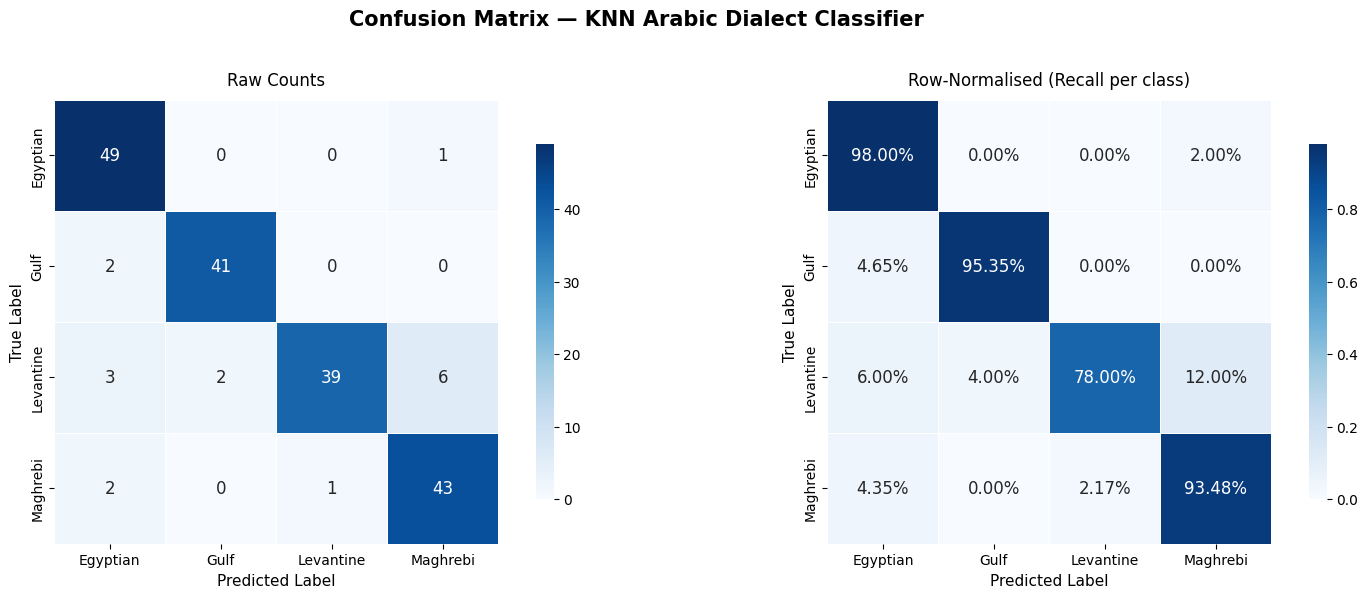

Figure saved as confusion_matrix.png


In [20]:
cm = confusion_matrix(y_test, y_pred)

# Normalised version (row-wise) for readability
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix — KNN Arabic Dialect Classifier",
             fontsize=15, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Raw Counts', 'Row-Normalised (Recall per class)']
):
    sns.heatmap(
        data,
        annot       = True,
        fmt         = fmt,
        cmap        = 'Blues',
        xticklabels = le.classes_,
        yticklabels = le.classes_,
        linewidths  = 0.5,
        linecolor   = 'white',
        square      = True,
        ax          = ax,
        annot_kws   = {'size': 12},
        cbar_kws    = {'shrink': 0.8},
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label",      fontsize=11)
    ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as confusion_matrix.png")

---
## Finding a Borderline Sample (Mixed Prediction)

We systematically scan the test set for a sample where no single dialect exceeds 70% probability — i.e., the model is genuinely uncertain — to demonstrate the smooth probability mixture behaviour.

Searching for an ambiguous / borderline test sample …
  Most uncertain test sample index : 5
  Highest single-class probability : 29.96%
  True dialect : Gulf

  ── Percentage Attribution for Borderline Sample ──
    Gulf        :  29.96%  ██████████████
    Maghrebi    :  29.46%  ██████████████
    Egyptian    :  20.58%  ██████████
    Levantine   :  19.99%  █████████


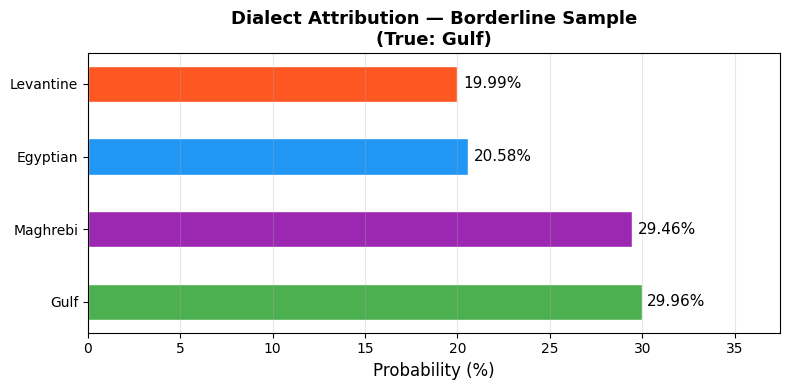

In [21]:
print("Searching for an ambiguous / borderline test sample …")

# Predict probabilities for the entire test set at once (fast)
all_probas = knn.predict_proba(X_test_scaled)   # (N_test, 4)
max_probas  = all_probas.max(axis=1)            # highest single-class probability

# Find the sample with the lowest maximum probability (most uncertain)
most_uncertain_idx = int(np.argmin(max_probas))
max_p = max_probas[most_uncertain_idx]

print(f"  Most uncertain test sample index : {most_uncertain_idx}")
print(f"  Highest single-class probability : {max_p*100:.2f}%")
print(f"  True dialect : {le.inverse_transform([y_test[most_uncertain_idx]])[0]}")

print("\n  ── Percentage Attribution for Borderline Sample ──")
proba_dict = dict(zip(le.classes_, all_probas[most_uncertain_idx] * 100))
for dialect, pct in sorted(proba_dict.items(), key=lambda x: -x[1]):
    bar = '█' * int(pct / 2)
    print(f"    {dialect:12s}: {pct:6.2f}%  {bar}")

# Bar chart of the borderline sample's probabilities
fig, ax = plt.subplots(figsize=(8, 4))
dialects_sorted = sorted(proba_dict.items(), key=lambda x: -x[1])
names = [d for d, _ in dialects_sorted]
pcts  = [p for _, p in dialects_sorted]
colors = [PALETTE_DICT[n] for n in names]

bars = ax.barh(names, pcts, color=colors, edgecolor='white', height=0.5)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=11)
ax.set_xlim(0, max(pcts) * 1.25)
ax.set_xlabel("Probability (%)", fontsize=12)
ax.set_title(
    f"Dialect Attribution — Borderline Sample\n"
    f"(True: {le.inverse_transform([y_test[most_uncertain_idx]])[0]})",
    fontsize=13, fontweight='bold'
)
ax.axvline(50, color='grey', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.savefig("borderline_prediction.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Summary Dashboard

A final single-figure summary combining the key metrics for reporting.

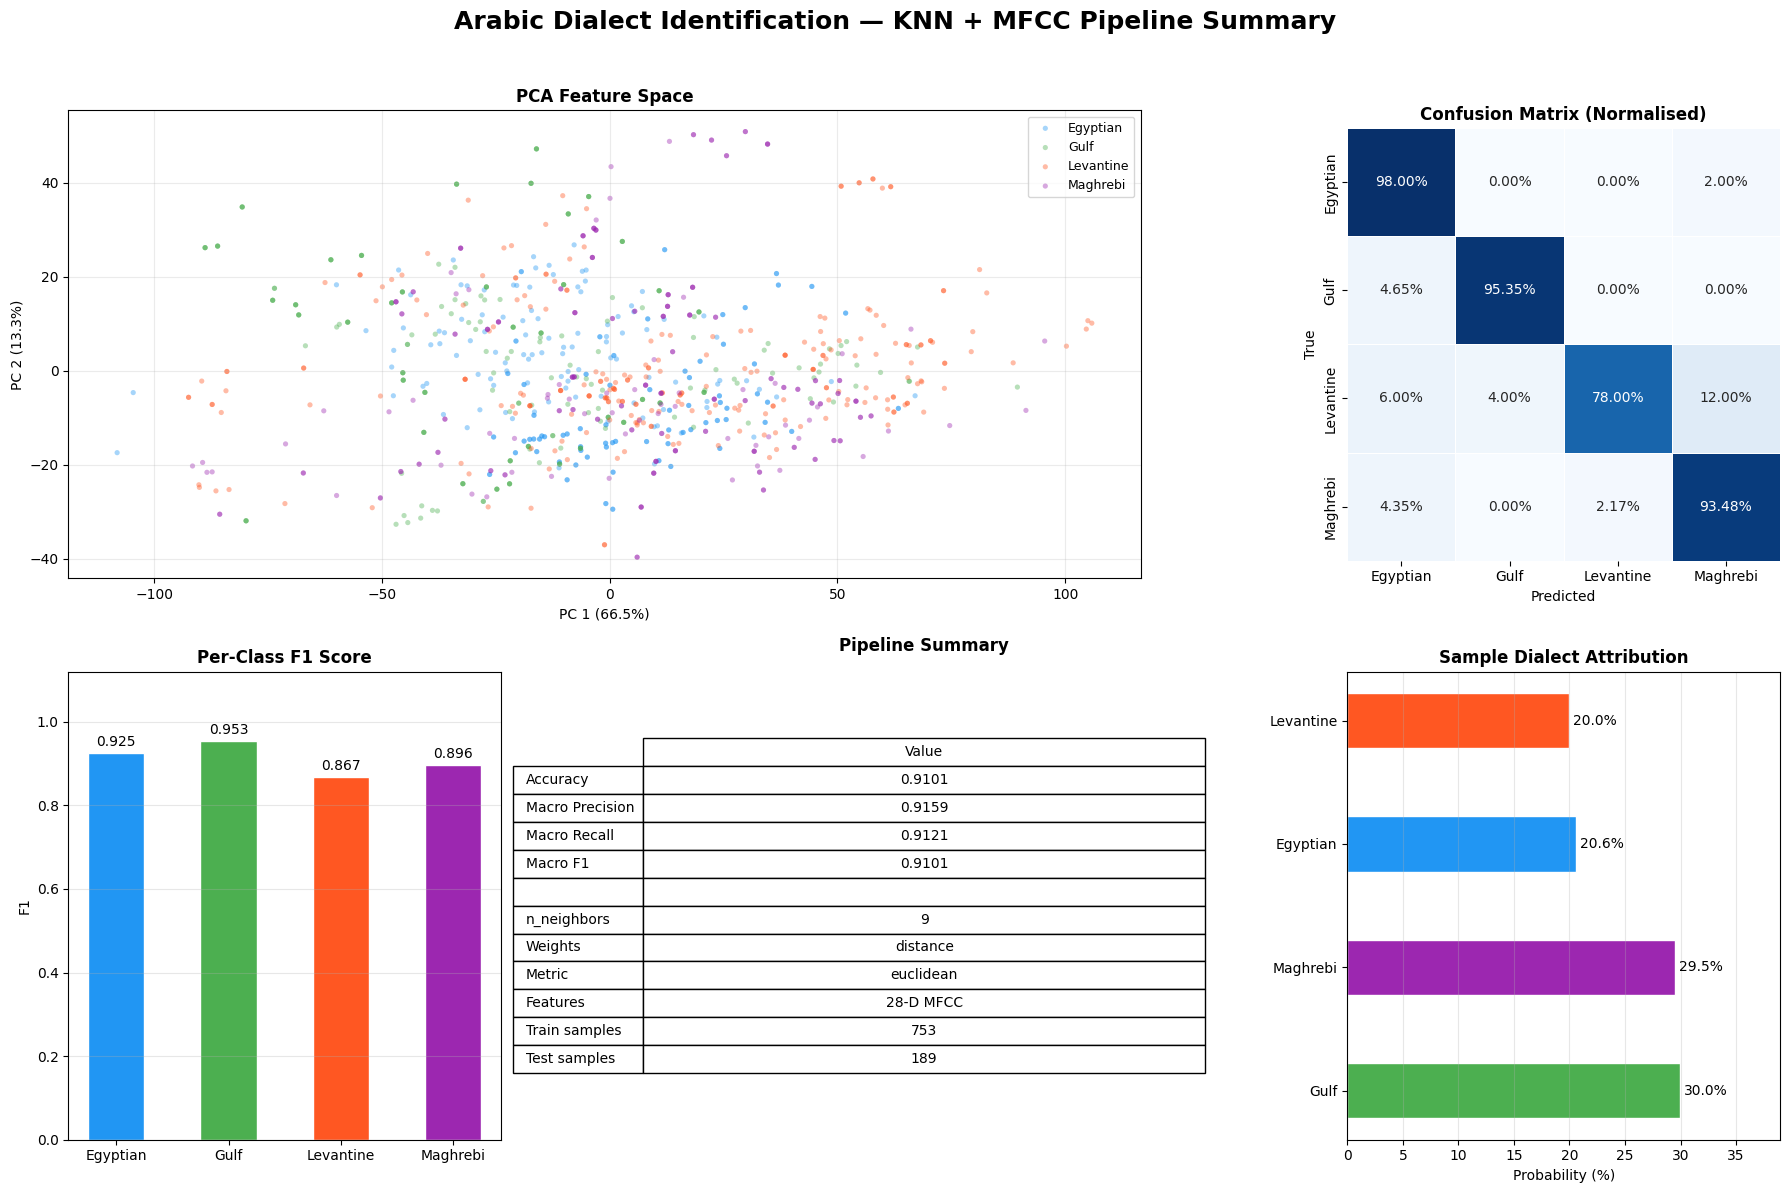

Summary dashboard saved as summary_dashboard.png


In [22]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    "Arabic Dialect Identification — KNN + MFCC Pipeline Summary",
    fontsize=18, fontweight='bold', y=0.99
)

# ── Top row: PCA scatter + confusion matrix ──
ax_pca = fig.add_subplot(2, 3, (1, 2))
for dialect in DIALECT_NAMES:
    sub = df_pca[df_pca['Dialect'] == dialect]
    ax_pca.scatter(sub['PC1'], sub['PC2'],
                   c=PALETTE_DICT[dialect], label=dialect,
                   alpha=0.40, s=14, edgecolors='none')
ax_pca.set_xlabel(f"PC 1 ({explained[0]:.1f}%)")
ax_pca.set_ylabel(f"PC 2 ({explained[1]:.1f}%)")
ax_pca.set_title("PCA Feature Space", fontsize=12, fontweight='bold')
ax_pca.legend(fontsize=9)
ax_pca.grid(True, alpha=0.25)

ax_cm = fig.add_subplot(2, 3, 3)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, square=True, ax=ax_cm,
    annot_kws={'size': 10}, cbar=False
)
ax_cm.set_title("Confusion Matrix (Normalised)", fontsize=12, fontweight='bold')
ax_cm.set_xlabel("Predicted")
ax_cm.set_ylabel("True")

# ── Bottom row: per-class F1 + metrics table ──
ax_f1 = fig.add_subplot(2, 3, 4)
per_class_f1 = f1_score(y_test, y_pred, average=None)
bars = ax_f1.bar(
    le.classes_, per_class_f1,
    color=[PALETTE_DICT[c] for c in le.classes_],
    edgecolor='white', width=0.5
)
ax_f1.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax_f1.set_ylim(0, 1.12)
ax_f1.set_title("Per-Class F1 Score", fontsize=12, fontweight='bold')
ax_f1.set_ylabel("F1")
ax_f1.grid(axis='y', alpha=0.3)

ax_metrics = fig.add_subplot(2, 3, 5)
ax_metrics.axis('off')
metric_data = [
    ['Metric', 'Value'],
    ['Accuracy',       f"{acc:.4f}"],
    ['Macro Precision',f"{prec:.4f}"],
    ['Macro Recall',   f"{rec:.4f}"],
    ['Macro F1',       f"{f1:.4f}"],
    ['', ''],
    ['n_neighbors',    str(knn.n_neighbors)],
    ['Weights',        knn.weights],
    ['Metric',         knn.metric],
    ['Features',       '28-D MFCC'],
    ['Train samples',  str(X_train.shape[0])],
    ['Test samples',   str(X_test.shape[0])],
]
tbl = ax_metrics.table(
    cellText  = [r[1:] for r in metric_data[1:]],
    rowLabels = [r[0]  for r in metric_data[1:]],
    colLabels = ['Value'],
    loc       = 'center',
    cellLoc   = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.5)
ax_metrics.set_title("Pipeline Summary", fontsize=12, fontweight='bold', pad=15)

ax_bar = fig.add_subplot(2, 3, 6)
names_sorted = sorted(proba_dict.items(), key=lambda x: -x[1])
ns  = [d for d, _ in names_sorted]
ps  = [p for _, p in names_sorted]
ax_bar.barh(ns, ps, color=[PALETTE_DICT[n] for n in ns],
            edgecolor='white', height=0.45)
ax_bar.bar_label(ax_bar.containers[0], fmt='%.1f%%', padding=3, fontsize=10)
ax_bar.set_xlim(0, max(ps) * 1.3)
ax_bar.set_title("Sample Dialect Attribution", fontsize=12, fontweight='bold')
ax_bar.set_xlabel("Probability (%)")
ax_bar.axvline(50, color='grey', linestyle='--', alpha=0.5)
ax_bar.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("summary_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Summary dashboard saved as summary_dashboard.png")

---
## Pipeline Complete ✅

### What was built

| Step | Detail |
|---|---|
| Dataset | `riotu-lab/ARCADE-full` — 4 dialects, ≤750 samples each |
| Audio preprocessing | 16 kHz mono, pre-emphasis α = 0.97 |
| Feature extraction | 14 MFCCs (n_fft=1103, n_mels=26, fmin=0) → 28-D mean/std vector |
| Normalisation | StandardScaler (fit on train split only) |
| Classifier | KNN (k=9, weights='distance', metric='euclidean') |
| Inference | `predict_proba()` → per-dialect percentage attribution |

### Output files
- `mel_spectrograms.png` — 4-panel Mel-spectrogram comparison
- `pca_scatter.png` — 2-D PCA projection of MFCC features
- `mfcc_boxplots.png` — selected feature distributions per dialect
- `confusion_matrix.png` — raw count + normalised heatmaps
- `borderline_prediction.png` — probability bar chart for ambiguous sample
- `summary_dashboard.png` — full pipeline summary in one figure

### Possible extensions (still classical ML)
- Grid-search over `n_neighbors` via `GridSearchCV`
- Replace KNN with SVM (RBF kernel) or Random Forest for comparison
- Add delta- and delta-delta MFCCs (MFCC velocity/acceleration) as extra features
- Extend to all dialects in ARCADE for a multi-class challenge

## Training HIGH-EFFICIENCY MODELS (Logistic Regression & LightGBM)

In [23]:
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

print("🚀 --- Training High-Efficiency Models --- \n")

# ---------------------------------------------------------
# 1. Logistic Regression (Multinomial)
# ---------------------------------------------------------
# Why it's efficient: Trains in milliseconds, uses practically zero RAM,
# and natively outputs beautifully calibrated probabilities for your slider.
print("--- Logistic Regression ---")
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

lr_preds = log_reg.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%\n")
# FIXED: Using le.classes_ instead of target_names
print(classification_report(y_test, lr_preds, target_names=le.classes_))


# ---------------------------------------------------------
# 2. LightGBM (Light Gradient Boosting Machine)
# ---------------------------------------------------------
# Why it's efficient: It builds trees leaf-wise instead of depth-wise,
# making it significantly faster and less memory-intensive than Random Forest or XGBoost.
print("\n--- LightGBM Classifier ---")
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=15, # Kept small to prevent overfitting on your small dataset
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores for maximum speed
)
lgb_model.fit(X_train_scaled, y_train)

lgb_preds = lgb_model.predict(X_test_scaled)
lgb_acc = accuracy_score(y_test, lgb_preds)

print(f"LightGBM Accuracy: {lgb_acc * 100:.2f}%\n")
# FIXED: Using le.classes_ instead of target_names
print(classification_report(y_test, lgb_preds, target_names=le.classes_))

🚀 --- Training High-Efficiency Models --- 

--- Logistic Regression ---
Logistic Regression Accuracy: 71.43%

              precision    recall  f1-score   support

    Egyptian       0.71      0.82      0.76        50
        Gulf       0.73      0.70      0.71        43
   Levantine       0.66      0.58      0.62        50
    Maghrebi       0.76      0.76      0.76        46

    accuracy                           0.71       189
   macro avg       0.71      0.71      0.71       189
weighted avg       0.71      0.71      0.71       189


--- LightGBM Classifier ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6941
[LightGBM] [Info] Number of data points in the train set: 753, number of used features: 28
[LightGBM] [Info] Start training from score -1.325748
[LightGBM] [Info] Start training from score -1.488267
[LightGBM] [Info] Start trainin

## Saving Models

In [24]:
import joblib
# Save the model
joblib.dump(knn, 'knn_dialect_classifier.pkl')
joblib.dump(lgb_model, 'lgb_dialecr_classifier.pkl')

['lgb_dialecr_classifier.pkl']